# Import Libraries, Class, Functions

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

utils_path = NOTEBOOK_DIR / "01_SGD_Quantile_Regression_Utils.ipynb"

In [ ]:
%run "$utils_path"

# Hardware

In [ ]:
import os
import platform
import psutil

print("CPU:", platform.processor())
print("Machine:", platform.machine())
print("Cores (logical):", os.cpu_count())
print("RAM (GB):", round(psutil.virtual_memory().total / 1e9, 2))

CPU: x86_64
Machine: x86_64
Cores (logical): 8
RAM (GB): 54.75


In [ ]:
import sys
import sklearn
import scipy
import statsmodels

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
SciPy: 1.16.3
statsmodels: 0.14.6


In [ ]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

NumPy: 2.0.2
pandas: 2.2.2


# Check Sklearn Compatibility

In [ ]:
from sklearn.utils.estimator_checks import check_estimator

In [ ]:
est = SGDQuantileRegressor(
    max_iter=100,
    batch_size=32,
    eval_every=5,
    random_state=0
)

check_estimator(est)
print('SGDQuantileRegressor passed all sklearn checks')

SGDQuantileRegressor passed all sklearn checks


# Challenging synthetic regimes

## Run experiment

In [ ]:
synthetic_table = pd.DataFrame([
    dict(
        experiment="Heteroskedastic",
        regime_label=r"Heteroskedastic ($\rho=0.99$, $h=1$)",
        n=10_000,
        d=100,
        lower_tau=0.025,
        upper_tau=0.975,
        rho=0.99,
        covariance="toeplitz",
        noise_dist="gaussian",
        heteroskedastic=True,
        hetero_strength=1.0,
    ),
    dict(
        experiment="Heavy-tailed",
        regime_label=r"Heavy-tailed (Student-$t$, df=3)",
        n=10_000,
        d=100,
        lower_tau=0.025,
        upper_tau=0.975,
        rho=0.0,
        covariance="identity",
        noise_dist="student_t",
        t_df=3,
        heteroskedastic=False,
    ),
    dict(
        experiment="Combined difficulty",
        regime_label=r"Combined difficulty ($t_3$, $\rho=0.97$, $h=1$)",
        n=10_000,
        d=100,
        lower_tau=0.025,
        upper_tau=0.975,
        rho=0.97,
        covariance="toeplitz",
        noise_dist="student_t",
        t_df=3,
        heteroskedastic=True,
        hetero_strength=1.0,
    ),
])

In [ ]:
sgd_kwargs_synth = dict(
    max_iter=2_000,
    base_lr=0.5,
    batch_size=256,
    l1=0.0,
    l2=0.0,
    eval_every=2_000,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    dtype=np.float64,
    verbose=False,
)

synthetic_results = run_synthetic_experiment_table(
    experiment_table=synthetic_table,
    mode="interval",
    methods=("lp", "proxsgd"),
    seeds=range(10),
    test_size=1000,
    default_sgd_kwargs=sgd_kwargs_synth,
)

In [ ]:
synthetic_results_path = TABLE_DIR / "synthetic_results.csv"
synthetic_results.to_csv(synthetic_results_path, index=False)

## Load results

In [ ]:
synthetic_results = pd.read_csv(TABLE_DIR / "synthetic_results.csv")

In [ ]:
synthetic_summary = summarize_synthetic_intervals(
    synthetic_results,
    group_cols=("experiment", "method"),
    metric_cols=("mean_test_pinball", "coverage", "mean_width"),
    digits=2,
)

synthetic_summary

,experiment,method,mean_test_pinball,coverage,mean_width
0,Combined difficulty,lp,0.60 $\pm$ 0.15,0.94 $\pm$ 0.01,27.64 $\pm$ 5.71
1,Combined difficulty,proxsgd,0.57 $\pm$ 0.14,0.95 $\pm$ 0.01,27.95 $\pm$ 5.82
2,Heavy-tailed,lp,0.13 $\pm$ 0.01,0.94 $\pm$ 0.01,6.49 $\pm$ 0.11
3,Heavy-tailed,proxsgd,0.13 $\pm$ 0.01,0.95 $\pm$ 0.01,7.04 $\pm$ 0.16
4,Heteroskedastic,lp,0.32 $\pm$ 0.07,0.93 $\pm$ 0.01,16.95 $\pm$ 3.77
5,Heteroskedastic,proxsgd,0.30 $\pm$ 0.07,0.95 $\pm$ 0.01,17.81 $\pm$ 3.88


In [ ]:
label_map = synthetic_table.set_index("experiment")["regime_label"].to_dict()

synthetic_paper_table = synthetic_summary.copy()

synthetic_paper_table["Regime"] = synthetic_paper_table["experiment"].map(label_map)

synthetic_paper_table["Method"] = synthetic_paper_table["method"].map({
    "lp": "LP",
    "proxsgd": "proxSGD",
})

synthetic_paper_table = synthetic_paper_table.rename(columns={
    "mean_test_pinball": "Test Pinball Loss",
    "coverage": "Coverage",
    "mean_width": 'Mean Width'
})

synthetic_paper_table = synthetic_paper_table[
    ["Regime", "Method", "Test Pinball Loss", "Coverage", "Mean Width"]
]

synthetic_paper_table

,Regime,Method,Test Pinball Loss,Coverage,Mean Width
0,"Combined difficulty ($t_3$, $\rho=0.97$, $h=1$)",LP,0.60 $\pm$ 0.15,0.94 $\pm$ 0.01,27.64 $\pm$ 5.71
1,"Combined difficulty ($t_3$, $\rho=0.97$, $h=1$)",proxSGD,0.57 $\pm$ 0.14,0.95 $\pm$ 0.01,27.95 $\pm$ 5.82
2,"Heavy-tailed (Student-$t$, df=3)",LP,0.13 $\pm$ 0.01,0.94 $\pm$ 0.01,6.49 $\pm$ 0.11
3,"Heavy-tailed (Student-$t$, df=3)",proxSGD,0.13 $\pm$ 0.01,0.95 $\pm$ 0.01,7.04 $\pm$ 0.16
4,"Heteroskedastic ($\rho=0.99$, $h=1$)",LP,0.32 $\pm$ 0.07,0.93 $\pm$ 0.01,16.95 $\pm$ 3.77
5,"Heteroskedastic ($\rho=0.99$, $h=1$)",proxSGD,0.30 $\pm$ 0.07,0.95 $\pm$ 0.01,17.81 $\pm$ 3.88


In [ ]:
latex_synthetic = synthetic_paper_table.to_latex(
    index=False,
    escape=False,
    column_format="llcc",
    caption="Synthetic challenging-regime results.",
    label="tab:synthetic_challenging",
)

print(latex_synthetic)

\begin{table}
\caption{Synthetic challenging-regime results.}
\label{tab:synthetic_challenging}
\begin{tabular}{llcc}
\toprule
Regime & Method & Test Pinball Loss & Coverage & Mean Width \\
\midrule
Combined difficulty ($t_3$, $\rho=0.97$, $h=1$) & LP & 0.60 $\pm$ 0.15 & 0.94 $\pm$ 0.01 & 27.64 $\pm$ 5.71 \\
Combined difficulty ($t_3$, $\rho=0.97$, $h=1$) & proxSGD & 0.57 $\pm$ 0.14 & 0.95 $\pm$ 0.01 & 27.95 $\pm$ 5.82 \\
Heavy-tailed (Student-$t$, df=3) & LP & 0.13 $\pm$ 0.01 & 0.94 $\pm$ 0.01 & 6.49 $\pm$ 0.11 \\
Heavy-tailed (Student-$t$, df=3) & proxSGD & 0.13 $\pm$ 0.01 & 0.95 $\pm$ 0.01 & 7.04 $\pm$ 0.16 \\
Heteroskedastic ($\rho=0.99$, $h=1$) & LP & 0.32 $\pm$ 0.07 & 0.93 $\pm$ 0.01 & 16.95 $\pm$ 3.77 \\
Heteroskedastic ($\rho=0.99$, $h=1$) & proxSGD & 0.30 $\pm$ 0.07 & 0.95 $\pm$ 0.01 & 17.81 $\pm$ 3.88 \\
\bottomrule
\end{tabular}
\end{table}



## Hyperparameter robustness

### Run experiment

In [ ]:
#hyperparameter grid
base_lrs = [1e-3, 1e-2, 1e-1, 5e-1, 1.0, 2.0, 5.0]
batch_sizes = [32, 64, 128, 256, 512, 1024, 2048]

In [ ]:
#reuse experiment table with added lr and batches
robustness_rows = []

for _, row in synthetic_table.iterrows():
    for base_lr in base_lrs:
        for batch_size in batch_sizes:
            new_row = row.to_dict()
            new_row["base_lr"] = base_lr
            new_row["batch_size"] = batch_size
            new_row["experiment_group"] = "hyperparameter_robustness"
            robustness_rows.append(new_row)

synthetic_robustness_table = pd.DataFrame(robustness_rows)

In [ ]:
#proxSGD
sgd_kwargs_robustness = dict(
    max_iter=5_000,
    l1=0.0,
    l2=0.0,
    eval_every=5_000,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    dtype=np.float64,
    verbose=False,
)

synthetic_robustness_sgd = run_synthetic_experiment_table(
    experiment_table=synthetic_robustness_table,
    mode="interval",
    methods=("proxsgd",),
    seeds=range(5),
    test_size=1000,
    default_sgd_kwargs=sgd_kwargs_robustness,
)

In [ ]:
robustness_sgd_path = TABLE_DIR / "robustness_results.csv"
synthetic_robustness_sgd.to_csv(robustness_sgd_path, index=False)

In [ ]:
# LP reference (does not use lr or batch so we use previous experiment table)
synthetic_robustness_lp = run_synthetic_experiment_table(
    experiment_table=synthetic_table,
    mode="interval",
    methods=("lp",),
    seeds=range(5),
    test_size=1000,
    default_sgd_kwargs=sgd_kwargs_robustness,
)

In [ ]:
robustness_lp_path = TABLE_DIR / "robustness_results_lp.csv"
synthetic_robustness_lp.to_csv(robustness_lp_path, index=False)

### Load results

In [ ]:
synthetic_robustness_sgd = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Quantile Regression/Data/robustness_results.csv')
synthetic_robustness_lp = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Quantile Regression/Data/robustness_results_lp.csv')

In [ ]:
group_cols=("experiment", "seed")
synthetic_robustness_results = pd.concat(
    [synthetic_robustness_sgd, synthetic_robustness_lp],
    ignore_index=True,
)

synthetic_robustness_results.head()

,Unnamed: 0,experiment,experiment_group,seed,method,lower_tau,upper_tau,nominal_coverage,n,n_train,...,n_iter_upper,lower_test_pinball,upper_test_pinball,mean_test_pinball,lower_train_kkt_grad_inf,upper_train_kkt_grad_inf,coverage,mean_width,crossing_rate,winkler
0,0,Heteroskedastic,hyperparameter_robustness,0,proxsgd,0.025,0.975,0.95,10000,9000,...,5000,0.308357,0.303551,0.305954,0.016597,0.015435,0.959,19.915355,0.0,24.476342
1,1,Heteroskedastic,hyperparameter_robustness,1,proxsgd,0.025,0.975,0.95,10000,9000,...,5000,0.184476,0.224945,0.204711,0.007518,0.008313,0.960,13.047891,0.0,16.376845
2,2,Heteroskedastic,hyperparameter_robustness,2,proxsgd,0.025,0.975,0.95,10000,9000,...,5000,0.296799,0.268247,0.282523,0.006723,0.007961,0.969,19.081799,0.0,22.601845
3,3,Heteroskedastic,hyperparameter_robustness,3,proxsgd,0.025,0.975,0.95,10000,9000,...,5000,0.274618,0.266628,0.270623,0.011401,0.011483,0.964,17.773073,0.0,21.649871
4,4,Heteroskedastic,hyperparameter_robustness,4,proxsgd,0.025,0.975,0.95,10000,9000,...,5000,0.428845,0.388875,0.408860,0.017090,0.016023,0.974,28.418284,0.0,32.708784


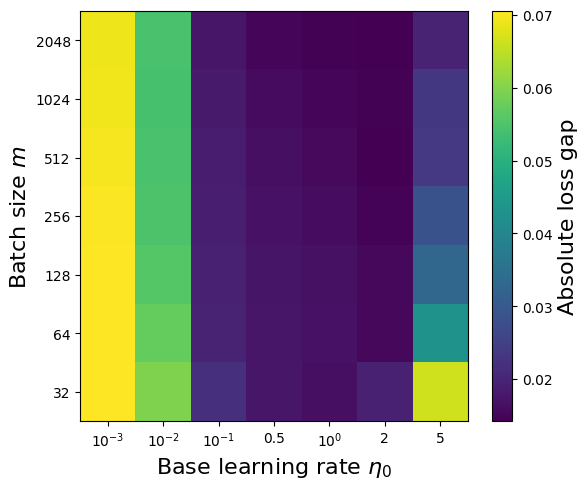

In [ ]:
lossgap_plot_df = plot_optimizer_lossgap(
    synthetic_robustness_results,
    metric_col="mean_test_pinball",
    reference_method="lp",
    target_method="proxsgd",
    group_cols=("experiment", "seed"),
    lr_col="base_lr",
    bs_col="batch_size",
    agg="mean",
    figsize=(6, 5),
    percentile_clip=95,
)

plt.savefig(
    FIGURE_DIR / "synthetic_loss_gap_heatmap.png",
    dpi=600,
    bbox_inches="tight",
)

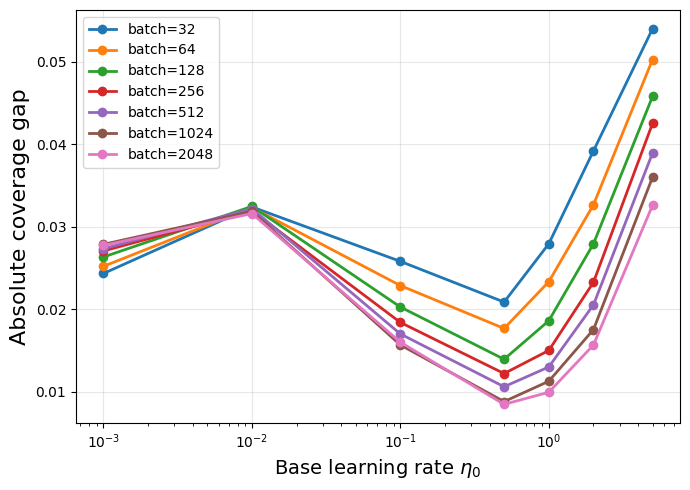

In [ ]:
coverage_gap_plot_df = plot_metric_vs_lr_by_batch(
    synthetic_robustness_results,
    metric_col="coverage",
    reference_method="lp",
    target_method="proxsgd",
    group_cols=("experiment", "seed"),
    lr_col="base_lr",
    bs_col="batch_size",
    agg="mean",
    absolute=True,
    ylabel="Absolute coverage gap",
    figsize=(7, 5),
)

plt.savefig(
    FIGURE_DIR / "synthetic_coverage_gap_by_learning_rate.png",
    dpi=600,
    bbox_inches="tight",
)

# Benchmark experiments

## No regularization

In [ ]:
# Unregularized benchmark interval table

benchmark_datasets = [
    "abalone",
    "concrete",
    "california",
]

benchmark_seeds = range(10)

benchmark_experiment_table = pd.DataFrame(
    [
        {
            "dataset": dataset,
            "random_state": seed,
            "lower_tau": 0.1,
            "upper_tau": 0.9,
            "test_size": 0.2,
            "lp_alpha": 0.0,
            "l1": 0.0,
            "methods": "lp, irls, proxsgd",
        }
        for dataset in benchmark_datasets
        for seed in benchmark_seeds
    ]
)

benchmark_sgd_kwargs = dict(
    max_iter=5_000,
    base_lr=0.5,
    batch_size=256,
    l1=0.0,
    l2=0.0,
    eval_every=5_000,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    early_stopping=False,
    dtype=np.float64,
    verbose=False,
)

benchmark_results = run_benchmark_experiment_table(
    benchmark_experiment_table,
    methods=("lp", "irls", "proxsgd"),
    test_size=0.2,
    default_sgd_kwargs=benchmark_sgd_kwargs,
    scale=True,
)

benchmark_interval_df = benchmark_results["interval"]
benchmark_point_df = benchmark_results["point"]

In [ ]:
benchmark_interval_summary = summarize_benchmark_intervals(
    benchmark_interval_df,
    group_cols=("dataset", "method"),
    metric_cols=(
        "lower_test_pinball",
        "coverage",
        "mean_width",
        "fit_seconds",
    ),
    digits=4,
)

benchmark_interval_summary

,dataset,method,lower_test_pinball,coverage,mean_width,fit_seconds
0,abalone,irls,0.2778 $\pm$ 0.0072,0.7888 $\pm$ 0.0106,4.9265 $\pm$ 0.1030,0.5217 $\pm$ 0.5081
1,abalone,lp,0.2778 $\pm$ 0.0072,0.7888 $\pm$ 0.0106,4.9265 $\pm$ 0.1030,1.8871 $\pm$ 0.2290
2,abalone,proxsgd,0.2776 $\pm$ 0.0072,0.7907 $\pm$ 0.0102,4.9447 $\pm$ 0.0819,1.9870 $\pm$ 0.4065
3,california,irls,0.0843 $\pm$ 0.0021,0.8011 $\pm$ 0.0093,1.4850 $\pm$ 0.0101,1.5457 $\pm$ 1.2868
4,california,lp,0.0843 $\pm$ 0.0021,0.8011 $\pm$ 0.0093,1.4850 $\pm$ 0.0100,38.0523 $\pm$ 3.9006
5,california,proxsgd,0.0843 $\pm$ 0.0020,0.8044 $\pm$ 0.0094,1.4902 $\pm$ 0.0085,4.7340 $\pm$ 1.0997
6,concrete,irls,1.7930 $\pm$ 0.0878,0.7782 $\pm$ 0.0313,26.4310 $\pm$ 0.7744,0.4993 $\pm$ 1.1651
7,concrete,lp,1.7930 $\pm$ 0.0878,0.7782 $\pm$ 0.0313,26.4311 $\pm$ 0.7744,0.2467 $\pm$ 0.1684
8,concrete,proxsgd,1.7909 $\pm$ 0.0949,0.7898 $\pm$ 0.0249,26.9058 $\pm$ 0.7506,2.0794 $\pm$ 1.4062


In [ ]:
benchmark_interval_summary = benchmark_interval_summary.rename(
    columns={
        "dataset": "Dataset",
        "method": "Method",
        "lower_test_pinball": "Pinball Loss",
        "coverage": "Coverage",
        "mean_width": "Mean Width",
        "fit_seconds": "Runtime",
    }
)

benchmark_interval_summary["Dataset"] = (
    benchmark_interval_summary["Dataset"]
    .replace({
        "abalone": "Abalone",
        "concrete": "Concrete",
        "california": "California Housing",
        "engel": "Engel",
    })
)

benchmark_interval_summary["Method"] = (
    benchmark_interval_summary["Method"]
    .replace({
        "lp": "LP",
        "irls": "IRLS",
        "proxsgd": "proxSGD",
    })
)

benchmark_interval_summary

,Dataset,Method,Pinball Loss,Coverage,Mean Width,Runtime
0,Abalone,IRLS,0.2778 $\pm$ 0.0072,0.7888 $\pm$ 0.0106,4.9265 $\pm$ 0.1030,0.5217 $\pm$ 0.5081
1,Abalone,LP,0.2778 $\pm$ 0.0072,0.7888 $\pm$ 0.0106,4.9265 $\pm$ 0.1030,1.8871 $\pm$ 0.2290
2,Abalone,proxSGD,0.2776 $\pm$ 0.0072,0.7907 $\pm$ 0.0102,4.9447 $\pm$ 0.0819,1.9870 $\pm$ 0.4065
3,California Housing,IRLS,0.0843 $\pm$ 0.0021,0.8011 $\pm$ 0.0093,1.4850 $\pm$ 0.0101,1.5457 $\pm$ 1.2868
4,California Housing,LP,0.0843 $\pm$ 0.0021,0.8011 $\pm$ 0.0093,1.4850 $\pm$ 0.0100,38.0523 $\pm$ 3.9006
5,California Housing,proxSGD,0.0843 $\pm$ 0.0020,0.8044 $\pm$ 0.0094,1.4902 $\pm$ 0.0085,4.7340 $\pm$ 1.0997
6,Concrete,IRLS,1.7930 $\pm$ 0.0878,0.7782 $\pm$ 0.0313,26.4310 $\pm$ 0.7744,0.4993 $\pm$ 1.1651
7,Concrete,LP,1.7930 $\pm$ 0.0878,0.7782 $\pm$ 0.0313,26.4311 $\pm$ 0.7744,0.2467 $\pm$ 0.1684
8,Concrete,proxSGD,1.7909 $\pm$ 0.0949,0.7898 $\pm$ 0.0249,26.9058 $\pm$ 0.7506,2.0794 $\pm$ 1.4062


In [ ]:
latex_benchmark_table = dataframe_to_latex_table(
    benchmark_interval_summary,
    caption=(
        r"Performance comparison on benchmark datasets (80/20 split), averaged "
        r"over 10 random train/test splits. Reported values are mean "
        r"$\pm 1$ standard deviation across seeds. Metrics include test pinball "
        r"loss at $\tau=0.1$, empirical coverage, and mean width of prediction "
        r"intervals. Runtime reports total fit time for both quantile models. "
        r"Across datasets, all methods achieve comparable predictive accuracy "
        r"and interval quality. In these moderate-scale settings, with "
        r"small-to-moderate sample sizes and relatively small feature dimensions, "
        r"the computational advantages of proxSGD are not yet realized."
    ),
    label="tab:benchmark_metrics",
    column_format="llrrrr",
    escape=False,
)

print(latex_benchmark_table)

\begin{table}
\caption{Performance comparison on benchmark datasets (80/20 split), averaged over 10 random train/test splits. Reported values are mean $\pm 1$ standard deviation across seeds. Metrics include test pinball loss at $\tau=0.1$, empirical coverage, and mean width of prediction intervals. Runtime reports total fit time for both quantile models. Across datasets, all methods achieve comparable predictive accuracy and interval quality. In these moderate-scale settings, with small-to-moderate sample sizes and relatively small feature dimensions, the computational advantages of proxSGD are not yet realized.}
\label{tab:benchmark_metrics}
\begin{tabular}{llrrrr}
\toprule
Dataset & Method & Pinball Loss & Coverage & Mean Width & Runtime \\
\midrule
Abalone & IRLS & 0.2778 $\pm$ 0.0072 & 0.7888 $\pm$ 0.0106 & 4.9265 $\pm$ 0.1030 & 0.5217 $\pm$ 0.5081 \\
Abalone & LP & 0.2778 $\pm$ 0.0072 & 0.7888 $\pm$ 0.0106 & 4.9265 $\pm$ 0.1030 & 1.8871 $\pm$ 0.2290 \\
Abalone & proxSGD & 0.2776 

In [ ]:
#engel data

engel_experiment_table = pd.DataFrame(
    [
        {
            "dataset": "engel",
            "random_state": seed,
            "lower_tau": 0.1,
            "upper_tau": 0.9,
            "test_size": 0.2,
            "lp_alpha": 0.0,
            "l1": 0.0,
            "methods": "lp, irls, proxsgd",
        }
        for seed in range(10)
    ]
)

engel_results = run_benchmark_experiment_table(
    engel_experiment_table,
    methods=("lp", "irls", "proxsgd"),
    test_size=0.2,
    default_sgd_kwargs=benchmark_sgd_kwargs,
    scale=True,
)

engel_interval_df = engel_results["interval"]

engel_interval_summary = summarize_benchmark_intervals(
    engel_interval_df,
    group_cols=("dataset", "method"),
    metric_cols=(
        "lower_test_pinball",
        "coverage",
        "mean_width",
        "fit_seconds",
    ),
    digits=4,
)

engel_interval_summary

,dataset,method,lower_test_pinball,coverage,mean_width,fit_seconds
0,engel,irls,18.9933 $\pm$ 6.4350,0.7851 $\pm$ 0.0535,236.0841 $\pm$ 20.9801,0.0325 $\pm$ 0.0218
1,engel,lp,18.9933 $\pm$ 6.4350,0.7851 $\pm$ 0.0535,236.0841 $\pm$ 20.9801,0.0226 $\pm$ 0.0054
2,engel,proxsgd,27.9547 $\pm$ 3.1825,0.8021 $\pm$ 0.0522,515.4889 $\pm$ 19.9855,0.9659 $\pm$ 0.2197


## Convergence plot

In [ ]:
dataset_names = ["abalone", "concrete"]
seeds = range(10)
tau = 0.1

lp_kwargs = dict(
    alpha=0.0,
    solver="highs",
)

irls_fit_kwargs = dict(
    vcov="robust",
    kernel="epa",
    bandwidth="hsheather",
    max_iter=3000,
    p_tol=1e-6,
)

sgd_init_kwargs = dict(
    max_iter=500,
    base_lr=0.5,
    batch_size=256,
    l1=0.0,
    l2=0.0,
    eval_every=1,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    early_stopping=False,
    dtype=np.float64,
    verbose=False,
)

sgd_fit_kwargs = dict(
    record_monitor_loss=True,
    record_train_kkt=False,
    record_monitor_kkt=False,
    store_param_path=False,
)

curves, refs = collect_convergence_results_with_references(
    dataset_names=dataset_names,
    seeds=seeds,
    tau=tau,
    estimator_cls=SGDQuantileRegressor,
    sgd_init_kwargs=sgd_init_kwargs,
    sgd_fit_kwargs=sgd_fit_kwargs,
    lp_kwargs=lp_kwargs,
    irls_fit_kwargs=irls_fit_kwargs,
    test_size=0.2,
    scale=True,
)

In [ ]:
prox_summary, ref_summary = summarize_convergence_results(curves, refs)
lp_irls_diff = compare_lp_irls_refs(refs)

print("proxSGD final loss summary:")
display(prox_summary)

print("LP/IRLS reference loss summary:")
display(ref_summary)

print("LP/IRLS absolute differences:")
display(lp_irls_diff)

proxSGD final loss summary:


,dataset,split,proxSGD_final_mean,proxSGD_final_std,proxSGD_final_min,proxSGD_final_max
0,abalone,test,0.277943,0.007638,0.264566,0.292410
1,abalone,train,0.270706,0.001824,0.267271,0.273935
2,concrete,test,1.788290,0.086051,1.642216,1.944234
3,concrete,train,1.735950,0.021880,1.694993,1.773205


LP/IRLS reference loss summary:


,dataset,method,split,ref_mean,ref_std,ref_min,ref_max
0,abalone,IRLS,test,0.277835,0.007219,0.267269,0.291612
1,abalone,IRLS,train,0.269594,0.001764,0.266266,0.272391
2,abalone,LP,test,0.277836,0.007219,0.267273,0.291612
3,abalone,LP,train,0.269594,0.001764,0.266266,0.272391
4,concrete,IRLS,test,1.792929,0.087959,1.645563,1.936775
5,concrete,IRLS,train,1.720792,0.021122,1.683294,1.755305
6,concrete,LP,test,1.793002,0.087824,1.646284,1.936774
7,concrete,LP,train,1.720792,0.021122,1.683294,1.755304


LP/IRLS absolute differences:


,dataset,split,mean_abs_diff,std_abs_diff,max_abs_diff
0,abalone,test,5.855763e-07,1.209983e-06,3.417380e-06
1,abalone,train,1.083028e-09,1.997373e-09,6.762815e-09
2,concrete,test,7.257025e-05,2.278660e-04,7.210802e-04
3,concrete,train,1.004763e-08,2.174450e-08,7.171248e-08


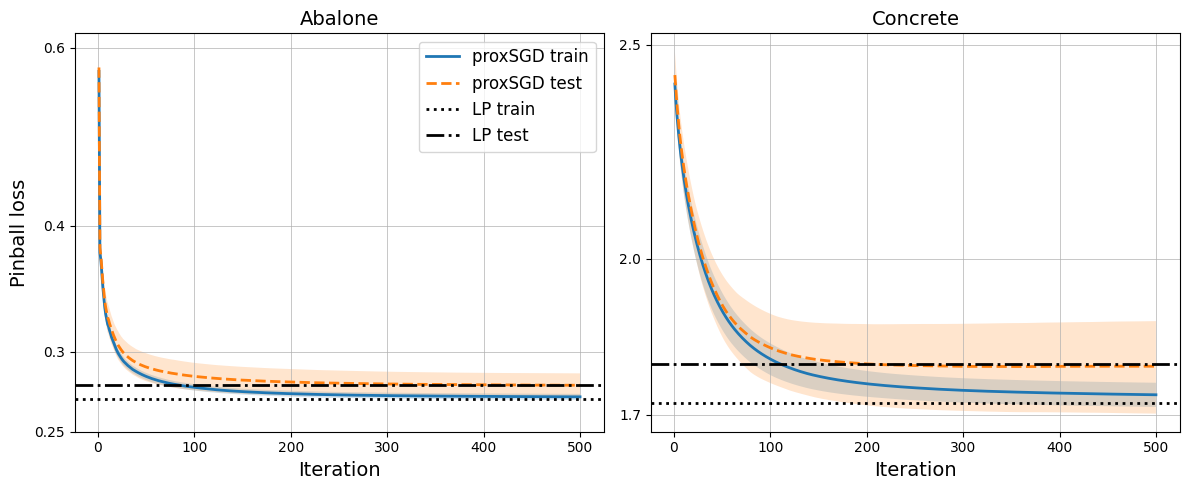

In [ ]:
dataset_labels = {
    "abalone": "Abalone",
    "concrete": "Concrete",
}

fig, axes = plot_convergence_with_references(
    curves=curves,
    refs=refs,
    dataset_names=["abalone", "concrete"],
    dataset_labels=dataset_labels,
    figsize_per_panel=(6, 5),
    use_log_scale=True,
)

plt.savefig(
    FIGURE_DIR / "benchmark_convergence.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

## $\ell_1$ Regularization

In [ ]:
# L1-regularized benchmark interval table
# LP vs proxSGD

regularized_benchmark_datasets = [
    "abalone",
    "concrete",
    "california",
]

regularized_seeds = range(10)

lambda1_table = 0.1

regularized_benchmark_experiment_table = pd.DataFrame(
    [
        {
            "dataset": dataset,
            "random_state": seed,
            "lower_tau": 0.1,
            "upper_tau": 0.9,
            "test_size": 0.2,
            "lp_alpha": lambda1_table,
            "l1": lambda1_table,
            "methods": "lp, proxsgd",
        }
        for dataset in regularized_benchmark_datasets
        for seed in regularized_seeds
    ]
)

regularized_benchmark_experiment_table.head()

,dataset,random_state,lower_tau,upper_tau,test_size,lp_alpha,l1,methods
0,abalone,0,0.1,0.9,0.2,0.1,0.1,"lp, proxsgd"
1,abalone,1,0.1,0.9,0.2,0.1,0.1,"lp, proxsgd"
2,abalone,2,0.1,0.9,0.2,0.1,0.1,"lp, proxsgd"
3,abalone,3,0.1,0.9,0.2,0.1,0.1,"lp, proxsgd"
4,abalone,4,0.1,0.9,0.2,0.1,0.1,"lp, proxsgd"


In [ ]:
regularized_sgd_kwargs = dict(
    max_iter=5_000,
    base_lr=0.5,
    batch_size=256,
    l1=lambda1_table,   # overwritten row-by-row by run_benchmark_experiment_table
    l2=0.0,
    eval_every=5_000,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    early_stopping=False,
    dtype=np.float64,
    verbose=False,
)

regularized_benchmark_results = run_benchmark_experiment_table(
    regularized_benchmark_experiment_table,
    methods=("lp", "proxsgd"),
    test_size=0.2,
    default_sgd_kwargs=regularized_sgd_kwargs,
    scale=True,
)

regularized_interval_df = regularized_benchmark_results["interval"]
regularized_point_df = regularized_benchmark_results["point"]

regularized_interval_df.head()

,dataset,random_state,method,lower_tau,upper_tau,nominal_coverage,n_train,n_test,d,lp_alpha,...,lower_test_pinball,upper_test_pinball,mean_test_pinball,rmse,coverage,mean_width,crossing_rate,winkler,lower_train_kkt_grad_inf,upper_train_kkt_grad_inf
0,abalone,0,lp,0.1,0.9,0.8,3341,836,9,0.1,...,0.321862,0.702392,0.512127,2.749066,0.802632,6.694636,0.0,10.242542,0.099965,0.104829
1,abalone,0,proxsgd,0.1,0.9,0.8,3341,836,9,0.1,...,0.322795,0.702245,0.512520,2.751692,0.802632,6.711888,0.0,10.250396,0.099850,0.084487
2,abalone,1,lp,0.1,0.9,0.8,3341,836,9,0.1,...,0.310383,0.673086,0.491734,2.657340,0.825359,6.665431,0.0,9.834689,0.095786,0.108228
3,abalone,1,proxsgd,0.1,0.9,0.8,3341,836,9,0.1,...,0.310377,0.672864,0.491621,2.655401,0.811005,6.658772,0.0,9.832410,0.098906,0.087962
4,abalone,2,lp,0.1,0.9,0.8,3341,836,9,0.1,...,0.332633,0.756100,0.544367,2.912407,0.800239,6.702733,0.0,10.887336,0.099162,0.099508


In [ ]:
regularized_interval_summary = summarize_benchmark_intervals(
    regularized_interval_df,
    group_cols=("dataset", "method"),
    metric_cols=(
        "lower_test_pinball",
        "coverage",
        "mean_width",
        "fit_seconds",
    ),
    digits=4,
)

regularized_interval_summary

,dataset,method,lower_test_pinball,coverage,mean_width,fit_seconds
0,abalone,lp,0.3186 $\pm$ 0.0102,0.8140 $\pm$ 0.0129,6.6573 $\pm$ 0.0389,1.0718 $\pm$ 0.5448
1,abalone,proxsgd,0.3185 $\pm$ 0.0103,0.8044 $\pm$ 0.0134,6.6624 $\pm$ 0.0411,3.0260 $\pm$ 1.7956
2,california,lp,0.1279 $\pm$ 0.0012,0.7995 $\pm$ 0.0072,2.4303 $\pm$ 0.0088,14.0230 $\pm$ 1.2140
3,california,proxsgd,0.1274 $\pm$ 0.0011,0.7996 $\pm$ 0.0071,2.4271 $\pm$ 0.0087,4.7289 $\pm$ 0.5798
4,concrete,lp,2.5495 $\pm$ 0.0497,0.8121 $\pm$ 0.0245,43.7103 $\pm$ 0.7393,0.1065 $\pm$ 0.0254
5,concrete,proxsgd,2.5491 $\pm$ 0.0498,0.8112 $\pm$ 0.0248,43.8934 $\pm$ 0.7414,1.3284 $\pm$ 0.2831


In [ ]:
regularized_interval_summary = regularized_interval_summary.rename(
    columns={
        "dataset": "Dataset",
        "method": "Method",
        "lower_test_pinball": "Pinball Loss",
        "coverage": "Coverage",
        "mean_width": "Mean Width",
        "fit_seconds": "Runtime",
    }
)

regularized_interval_summary["Dataset"] = (
    regularized_interval_summary["Dataset"]
    .replace({
        "abalone": "Abalone",
        "concrete": "Concrete",
        "california": "California Housing",
        "engel": "Engel",
    })
)

regularized_interval_summary["Method"] = (
    regularized_interval_summary["Method"]
    .replace({
        "lp": "LP",
        "proxsgd": "proxSGD",
    })
)

regularized_interval_summary

,Dataset,Method,Pinball Loss,Coverage,Mean Width,Runtime
0,Abalone,LP,0.3186 $\pm$ 0.0102,0.8140 $\pm$ 0.0129,6.6573 $\pm$ 0.0389,1.0718 $\pm$ 0.5448
1,Abalone,proxSGD,0.3185 $\pm$ 0.0103,0.8044 $\pm$ 0.0134,6.6624 $\pm$ 0.0411,3.0260 $\pm$ 1.7956
2,California Housing,LP,0.1279 $\pm$ 0.0012,0.7995 $\pm$ 0.0072,2.4303 $\pm$ 0.0088,14.0230 $\pm$ 1.2140
3,California Housing,proxSGD,0.1274 $\pm$ 0.0011,0.7996 $\pm$ 0.0071,2.4271 $\pm$ 0.0087,4.7289 $\pm$ 0.5798
4,Concrete,LP,2.5495 $\pm$ 0.0497,0.8121 $\pm$ 0.0245,43.7103 $\pm$ 0.7393,0.1065 $\pm$ 0.0254
5,Concrete,proxSGD,2.5491 $\pm$ 0.0498,0.8112 $\pm$ 0.0248,43.8934 $\pm$ 0.7414,1.3284 $\pm$ 0.2831


In [ ]:
latex_regularized_benchmark_table = dataframe_to_latex_table(
    regularized_interval_summary,
    caption=(
        rf"Performance comparison between LP and proxSGD for "
        rf"$\ell_1$-regularized quantile regression with "
        rf"$\lambda_1={lambda1_table}$ on benchmark datasets "
        rf"(80/20 split), averaged over 10 random train/test splits. "
        rf"Reported values are mean $\pm 1$ standard deviation across seeds "
        rf"(pinball loss corresponds to $\tau=0.1$ on the test split). "
        rf"Across datasets, both methods yield nearly identical predictive "
        rf"accuracy and interval quality. Additional experiments over a range "
        rf"of regularization parameters show consistent agreement, with "
        rf"proxSGD becoming computationally competitive on the larger "
        rf"California Housing data."
    ),
    label="tab:benchmark_metrics_regularized",
    column_format="llrrrr",
    escape=False,
)

print(latex_regularized_benchmark_table)

\begin{table}
\caption{Performance comparison between LP and proxSGD for $\ell_1$-regularized quantile regression with $\lambda_1=0.1$ on benchmark datasets (80/20 split), averaged over 10 random train/test splits. Reported values are mean $\pm 1$ standard deviation across seeds (pinball loss corresponds to $\tau=0.1$ on the test split). Across datasets, both methods yield nearly identical predictive accuracy and interval quality. Additional experiments over a range of regularization parameters show consistent agreement, with proxSGD becoming computationally competitive on the larger California Housing data.}
\label{tab:benchmark_metrics_regularized}
\begin{tabular}{llrrrr}
\toprule
Dataset & Method & Pinball Loss & Coverage & Mean Width & Runtime \\
\midrule
Abalone & LP & 0.3186 $\pm$ 0.0102 & 0.8140 $\pm$ 0.0129 & 6.6573 $\pm$ 0.0389 & 1.0718 $\pm$ 0.5448 \\
Abalone & proxSGD & 0.3185 $\pm$ 0.0103 & 0.8044 $\pm$ 0.0134 & 6.6624 $\pm$ 0.0411 & 3.0260 $\pm$ 1.7956 \\
California Housin

In [ ]:
lambda1_grid = [0.001, 0.005, 0.1, 0.5]

regularized_grid_experiment_table = pd.DataFrame(
    [
        {
            "dataset": dataset,
            "random_state": seed,
            "lower_tau": 0.1,
            "upper_tau": 0.9,
            "test_size": 0.2,
            "lp_alpha": lambda1,
            "l1": lambda1,
            "lambda1": lambda1,
            "methods": "lp, proxsgd",
        }
        for dataset in regularized_benchmark_datasets
        for lambda1 in lambda1_grid
        for seed in regularized_seeds
    ]
)

regularized_grid_results = run_benchmark_experiment_table(
    regularized_grid_experiment_table,
    methods=("lp", "proxsgd"),
    test_size=0.2,
    default_sgd_kwargs=regularized_sgd_kwargs,
    scale=True,
)

regularized_grid_interval_df = regularized_grid_results["interval"]
regularized_grid_point_df = regularized_grid_results["point"]

In [ ]:
regularized_grid_summary = summarize_benchmark_intervals(
    regularized_grid_interval_df,
    group_cols=("dataset", "l1", "method"),
    metric_cols=(
        "lower_test_pinball",
        "coverage",
        "mean_width",
        "fit_seconds",
    ),
    digits=4,
)

regularized_grid_summary

,dataset,l1,method,lower_test_pinball,coverage,mean_width,fit_seconds
0,abalone,0.001,lp,0.2782 $\pm$ 0.0072,0.7901 $\pm$ 0.0099,4.9188 $\pm$ 0.0844,1.8853 $\pm$ 0.5000
1,abalone,0.001,proxsgd,0.2780 $\pm$ 0.0074,0.7911 $\pm$ 0.0103,4.9478 $\pm$ 0.0669,1.9554 $\pm$ 0.3153
2,abalone,0.005,lp,0.2817 $\pm$ 0.0080,0.7917 $\pm$ 0.0109,4.9732 $\pm$ 0.0601,1.5512 $\pm$ 0.3895
3,abalone,0.005,proxsgd,0.2813 $\pm$ 0.0080,0.7939 $\pm$ 0.0101,4.9808 $\pm$ 0.0577,2.0787 $\pm$ 0.3411
4,abalone,0.100,lp,0.3186 $\pm$ 0.0102,0.8140 $\pm$ 0.0129,6.6573 $\pm$ 0.0389,0.8974 $\pm$ 0.1995
5,abalone,0.100,proxsgd,0.3185 $\pm$ 0.0103,0.8044 $\pm$ 0.0134,6.6624 $\pm$ 0.0411,2.2190 $\pm$ 0.7184
6,abalone,0.500,lp,0.4641 $\pm$ 0.0097,0.8681 $\pm$ 0.0110,8.0000 $\pm$ 0.0000,0.8395 $\pm$ 0.1831
7,abalone,0.500,proxsgd,0.4642 $\pm$ 0.0098,0.8001 $\pm$ 0.0227,7.9840 $\pm$ 0.0061,2.0288 $\pm$ 0.2973
8,california,0.001,lp,0.0845 $\pm$ 0.0016,0.8010 $\pm$ 0.0092,1.4878 $\pm$ 0.0097,34.5159 $\pm$ 0.5663
9,california,0.001,proxsgd,0.0844 $\pm$ 0.0016,0.8049 $\pm$ 0.0092,1.4935 $\pm$ 0.0072,4.5337 $\pm$ 0.4962


# CPS

## Load Data

In [ ]:
CPS_CLEAN_DIR = DATA_DIR / "ipums_clean_chunks"

if not CPS_CLEAN_DIR.exists():
    raise FileNotFoundError(
        f"CPS data directory not found: {CPS_CLEAN_DIR}\n"
        "Raw CPS data are not included in this repository. "
        "Place cleaned CPS files named clean_part_*.csv in data/ipums_clean_chunks/."
    )

clean_files = sorted(CPS_CLEAN_DIR.glob("clean_part_*.csv"))

if len(clean_files) == 0:
    raise FileNotFoundError(
        f"No cleaned CPS files found in {CPS_CLEAN_DIR}. "
        "Expected files named clean_part_*.csv."
    )

df_cps = pd.concat(
    [pd.read_csv(path) for path in clean_files],
    ignore_index=True,
)

print(f"CPS cleaned data shape: {df_cps.shape}")
display(df_cps.head())

CPS cleaned data shape: (1071058, 13)


,log_wage,AGE,EDUC,SEX,RACE,HISPAN,REGION,STATEFIP,OCC,IND,UNION,YEAR,MONTH
0,2.517696,49,73,2,100,0,11,23,4020,7860,1,2009,3
1,2.708050,38,91,1,100,0,11,23,8760,3960,1,2009,3
2,3.113515,41,81,2,100,0,11,23,350,8270,1,2009,3
3,2.251292,59,73,1,100,0,11,23,4720,5090,1,2009,3
4,1.981001,40,73,2,100,0,11,23,4020,1190,1,2009,3


In [ ]:
# Match the column name expected by prepare_cps_features
if "STATE" not in df_cps.columns and "STATEFIP" in df_cps.columns:
    df_cps = df_cps.rename(columns={"STATEFIP": "STATE"})

df_cps.shape, df_cps.columns

((1071058, 13),
 Index(['log_wage', 'AGE', 'EDUC', 'SEX', 'RACE', 'HISPAN', 'REGION', 'STATE',
        'OCC', 'IND', 'UNION', 'YEAR', 'MONTH'],
       dtype='object'))

## proxSGD

In [ ]:
CPS_RESULTS_DIR = TABLE_DIR

N_TEST = 50_000
SEED = 123
taus = (0.1, 0.5, 0.9)

sgd_kwargs = dict(
    max_iter=10_000,
    base_lr=0.5,
    batch_size=1024,
    l1=0.0,
    l2=0.0,
    eval_every=10_000,
    use_adagrad=True,
    adagrad_eps=1e-8,
    use_averaging=True,
    early_stopping=False,
    dtype=np.float64,
    verbose=False,
    random_state=SEED,
)

In [ ]:
# proxSGD CPS scaling experiment

df_prox = run_cps_scaling_experiment(
    df_cps,
    N_SUB_list=[
        10_000,
        25_000,
        50_000,
        75_000,
        100_000,
        250_000,
        500_000,
        750_000,
        1_000_000,
    ],
    taus=taus,
    methods=("proxsgd",),
    seed=SEED,
    test_size=N_TEST,
    lp_alpha=0.0,
    sgd_kwargs=sgd_kwargs,
)

prox_path = CPS_RESULTS_DIR / "cps_qr_scaling_results_proxsgd.csv"
df_prox.to_csv(prox_path, index=False)

df_prox

## IRLS

In [ ]:
# IRLS CPS scaling experiment

df_irls = run_cps_scaling_experiment(
    df_cps,
    N_SUB_list=[
        10_000,
        25_000,
        50_000,
        75_000,
        100_000,
        250_000,
        500_000,
    ],
    taus=taus,
    methods=("irls",),
    seed=SEED,
    test_size=N_TEST,
    lp_alpha=0.0,
    irls_max_iter=3000,
    irls_p_tol=1e-6,
    sgd_kwargs=None,
)

irls_path = CPS_RESULTS_DIR / "cps_qr_scaling_results_irls.csv"
df_irls.to_csv(irls_path, index=False)

df_irls

## LP

In [ ]:
# LP CPS scaling experiment

df_lp = run_cps_scaling_experiment(
    df_cps,
    N_SUB_list=[
        10_000,
        25_000,
        50_000,
        75_000,
        100_000,
        250_000,
    ],
    taus=taus,
    methods=("lp",),
    seed=SEED,
    test_size=N_TEST,
    lp_alpha=0.0,
    sgd_kwargs=None,
)

lp_path = CPS_RESULTS_DIR / "cps_qr_scaling_results_lp.csv"
df_lp.to_csv(lp_path, index=False)

df_lp

## Load and combine

In [ ]:
#Load and combine
df_sgd = pd.read_csv(CPS_RESULTS_DIR / "cps_qr_scaling_results_proxsgd.csv")
df_irls = pd.read_csv(CPS_RESULTS_DIR / "cps_qr_scaling_results_irls.csv")
df_lp = pd.read_csv(CPS_RESULTS_DIR / "cps_qr_scaling_results_lp.csv")

df_cps_scaling = pd.concat(
    [df_lp, df_irls, df_sgd],
    ignore_index=True,
)

method_labels = {
    "lp": "LP",
    "irls": "IRLS",
    "proxsgd": "proxSGD",
}

df_cps_scaling["method_label"] = (
    df_cps_scaling["method"]
    .replace(method_labels)
)

combined_path = f"{CPS_RESULTS_DIR}/cps_qr_scaling_results_combined.csv"
df_cps_scaling.to_csv(combined_path, index=False)

df_cps_scaling

In [ ]:
# ============================================================
# Convert long CPS results to runtime plotting format
# ============================================================

df_cps_runtime = (
    df_cps_scaling
    .query("metric == 'fit_seconds'")
    .copy()
)

df_cps_runtime["fit_seconds"] = pd.to_numeric(df_cps_runtime["value"], errors="coerce")
df_cps_runtime["N_SUB"] = pd.to_numeric(df_cps_runtime["N_SUB"], errors="coerce")

df_cps_runtime["method"] = (
    df_cps_runtime["method"]
    .replace({
        "lp": "LP",
        "sklearn_LP": "LP",
        "IRLS": "IRLS",
        "irls": "IRLS",
        "proxsgd": "proxSGD",
        "proxSGD": "proxSGD",
    })
)

df_cps_runtime = df_cps_runtime.dropna(subset=["N_SUB", "fit_seconds"])

display(df_cps_runtime.head())

,seed,N_SUB,split,kind,method,tau,metric,value,method_label,fit_seconds
0,123,10000,train,timing,LP,0.1,fit_seconds,10.212599,sklearn_LP,10.212599
2,123,10000,train,timing,LP,0.5,fit_seconds,12.149267,sklearn_LP,12.149267
4,123,10000,train,timing,LP,0.9,fit_seconds,10.340890,sklearn_LP,10.340890
43,123,25000,train,timing,LP,0.1,fit_seconds,60.342951,sklearn_LP,60.342951
45,123,25000,train,timing,LP,0.5,fit_seconds,70.734858,sklearn_LP,70.734858


## Runtime plot

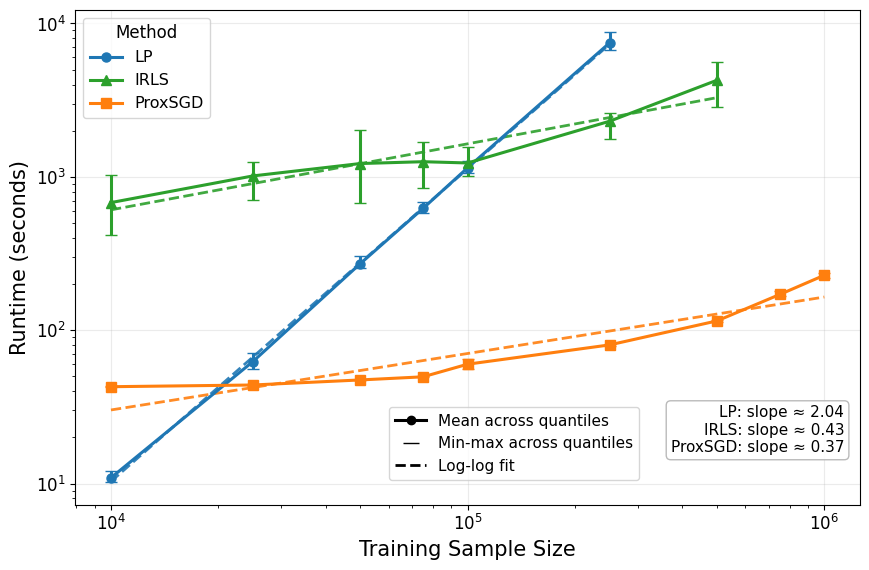

In [ ]:
fig, ax = plot_cps_runtime_scaling(
    df_cps_scaling,
    save_path=FIGURE_DIR / "cps_runtime_scaling.png",
)

plt.show()

## Coverage and width plots

In [ ]:
method_styles = {
    "sklearn_LP": {"label": "LP", "color": "C0", "linestyle": "-"},
    "lp": {"label": "LP", "color": "C0", "linestyle": "-"},
    "LP": {"label": "LP", "color": "C0", "linestyle": "-"},

    "IRLS": {"label": "IRLS", "color": "C2", "linestyle": "--"},
    "irls": {"label": "IRLS", "color": "C2", "linestyle": "--"},

    "proxSGD": {"label": "proxSGD", "color": "C1", "linestyle": ":"},
    "proxsgd": {"label": "proxSGD", "color": "C1", "linestyle": ":"},
    "ProxSGD": {"label": "proxSGD", "color": "C1", "linestyle": ":"},
}

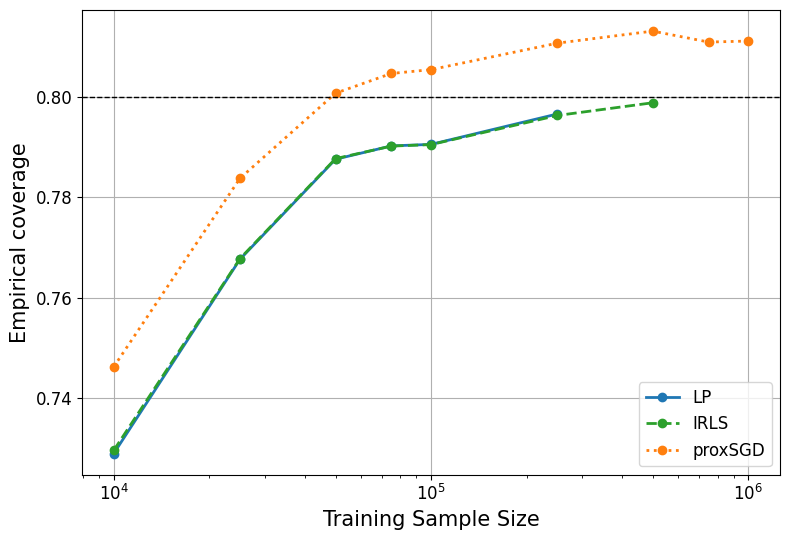

In [ ]:
fig, ax = plot_cps_coverage_scaling(
    df_cps_scaling,
    method_styles=method_styles,
    figsize=(8, 5.5),
    nominal=0.8,
)

plt.savefig(
    FIGURE_DIR / "cps_coverage_scaling.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

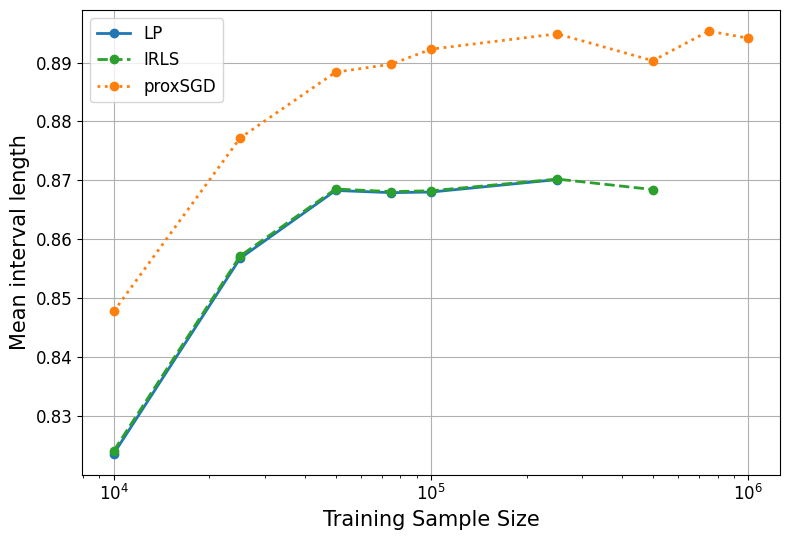

In [ ]:
fig, ax = plot_cps_width_scaling(
    df_cps_scaling,
    method_styles=method_styles,
    figsize=(8, 5.5),
)

plt.savefig(
    FIGURE_DIR / "cps_width_scaling.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()